In [1]:
import subprocess, sys
for p in ['tensorflow','scikit-learn','matplotlib','seaborn','pandas','numpy','Pillow']:
    subprocess.run([sys.executable,'-m','pip','install','-q',p], check=False)
print('All packages ready.')

All packages ready.


In [2]:
import os, warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU") or "None (CPU)"}')

TensorFlow: 2.21.0
GPU: None (CPU)


In [3]:
TRAIN_CSV  = 'mnist_train.csv'
TEST_CSV   = 'mnist_test.csv'
MODEL_PATH = 'mnist_cnn.h5'

print('Loading...')
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)
print(f'Train: {train_df.shape}  Test: {test_df.shape}')
print('\nLabel counts:')
print(train_df['label'].value_counts().sort_index())

Loading...
Train: (60000, 785)  Test: (10000, 785)

Label counts:
label
0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64


In [4]:
IMG_SIZE    = 28
NUM_CLASSES = 10

def df_to_arrays(df):
    y = df['label'].values.astype(np.int32)
    X = df.drop(columns=['label']).values.astype(np.float32) / 255.0
    X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
    return X, y

X_all,  y_all  = df_to_arrays(train_df)
X_test, y_test = df_to_arrays(test_df)

X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.1, random_state=42, stratify=y_all
)

y_train_oh = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_oh   = tf.keras.utils.to_categorical(y_val,   NUM_CLASSES)
y_test_oh  = tf.keras.utils.to_categorical(y_test,  NUM_CLASSES)

print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')
print(f'Pixel range: {X_train.min():.2f} – {X_train.max():.2f}')

Train: (54000, 28, 28, 1)  Val: (6000, 28, 28, 1)  Test: (10000, 28, 28, 1)
Pixel range: 0.00 – 1.00


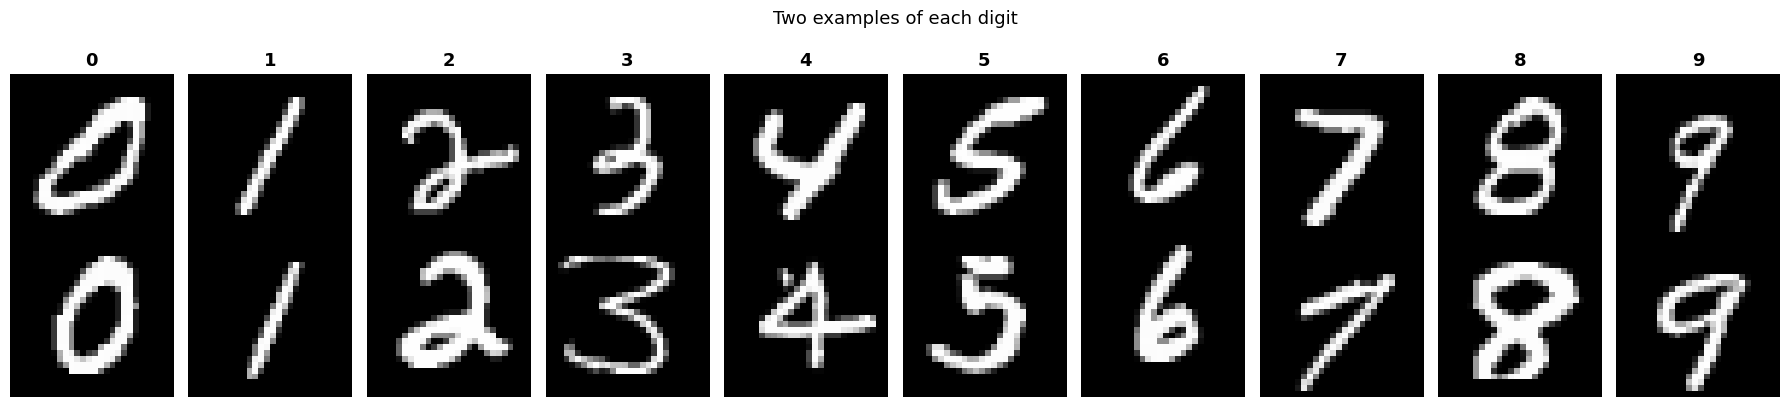

In [5]:
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
for d in range(10):
    for row, nth in enumerate([0, 1]):
        idx = np.where(y_train == d)[0][nth]
        axes[row, d].imshow(X_train[idx,:,:,0], cmap='gray')
        if row == 0:
            axes[row, d].set_title(str(d), fontsize=13, fontweight='bold')
        axes[row, d].axis('off')
plt.suptitle('Two examples of each digit', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [6]:
datagen = ImageDataGenerator(
    rotation_range=12,
    width_shift_range=0.12,
    height_shift_range=0.12,
    zoom_range=0.12,
    shear_range=0.10,
    fill_mode='constant',
    cval=0.0,
)
datagen.fit(X_train)
print('Augmentation ready.')

Augmentation ready.


In [7]:
def build_cnn(input_shape=(28, 28, 1), num_classes=10):
    reg = keras.regularizers.l2(1e-4)
    inp = keras.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, 3, padding='same', activation='relu', kernel_initializer='he_normal')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 2
    x = layers.Conv2D(64, 3, padding='same', activation='relu', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 3
    x = layers.Conv2D(128, 3, padding='same', activation='relu', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)

    # Head
    x = layers.Dense(256, activation='relu', kernel_regularizer=reg, kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inp, out, name='MNIST_DeepCNN')

model = build_cnn()
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()
print(f'\nParameters: {model.count_params():,}')

Model: "MNIST_DeepCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             

 Total params: 324,842 (1.24 MB)

 Trainable params: 323,434 (1.23 MB)

 Non-trainable params: 1,408 (5.50 KB)


Parameters: 324,842


In [8]:
BATCH_SIZE = 128
EPOCHS     = 50

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10,
                  restore_best_weights=True, verbose=1, min_delta=0.0001),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint(MODEL_PATH, monitor='val_accuracy',
                    save_best_only=True, verbose=1),
]

steps = len(X_train) // BATCH_SIZE
print(f'Steps/epoch: {steps}  |  Max epochs: {EPOCHS}')

history = model.fit(
    datagen.flow(X_train, y_train_oh, batch_size=BATCH_SIZE),
    steps_per_epoch=steps,
    validation_data=(X_val, y_val_oh),
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

ran  = len(history.history['accuracy'])
best = max(history.history['val_accuracy'])
print(f'\nRan {ran}/{EPOCHS} epochs  |  Best val acc: {best*100:.2f}%')

Steps/epoch: 421  |  Max epochs: 50
Epoch 1/50
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.7338 - loss: 0.9200
Epoch 1: val_accuracy improved from None to 0.97450, saving model to mnist_cnn.h5



Epoch 1: finished saving model to mnist_cnn.h5
421/421 ━━━━━━━━━━━━━━━━━━━━ 45s 99ms/step - accuracy: 0.8743 - loss: 0.4547 - val_accuracy: 0.9745 - val_loss: 0.1372 - learning_rate: 0.0010
Epoch 2/50
  1/421 ━━━━━━━━━━━━━━━━━━━━ 44s 107ms/step - accuracy: 0.9922 - loss: 0.0844
Epoch 2: val_accuracy did not improve from 0.97450
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9922 - loss: 0.0844 - val_accuracy: 0.9742 - val_loss: 0.1379 - learning_rate: 0.0010
Epoch 3/50
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9677 - loss: 0.1529
Epoch 3: val_accuracy improved from 0.97450 to 0.98433, saving model to mnist_cnn.h5



Epoch 3: finished saving model to mnist_cnn.h5
421/421 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.9706 - loss: 0.1430 - val_accuracy: 0.9843 - val_loss: 0.0951 - learning_rate: 0.0010
Epoch 4/50
  1/421 ━━━━━━━━━━━━━━━━━━━━ 39s 95ms/step - accuracy: 0.9688 - loss: 0.1071
Epoch 4: val_accuracy improved from 0.98433 to 0.98467, saving model to mnist_cnn.h5



Epoch 4: finished saving model to mnist_cnn.h5
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9688 - loss: 0.1071 - val_accuracy: 0.9847 - val_loss: 0.0955 - learning_rate: 0.0010
Epoch 5/50
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9773 - loss: 0.1198
Epoch 5: val_accuracy improved from 0.98467 to 0.98717, saving model to mnist_cnn.h5



Epoch 5: finished saving model to mnist_cnn.h5
421/421 ━━━━━━━━━━━━━━━━━━━━ 41s 98ms/step - accuracy: 0.9785 - loss: 0.1153 - val_accuracy: 0.9872 - val_loss: 0.0794 - learning_rate: 0.0010
Epoch 6/50
  1/421 ━━━━━━━━━━━━━━━━━━━━ 49s 118ms/step - accuracy: 0.9766 - loss: 0.0868
Epoch 6: val_accuracy did not improve from 0.98717
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9766 - loss: 0.0868 - val_accuracy: 0.9867 - val_loss: 0.0796 - learning_rate: 0.0010
Epoch 7/50
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9818 - loss: 0.0982
Epoch 7: val_accuracy improved from 0.98717 to 0.98967, saving model to mnist_cnn.h5


...


Epoch 16: finished saving model to mnist_cnn.h5
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9844 - loss: 0.0523 - val_accuracy: 0.9918 - val_loss: 0.0477 - learning_rate: 0.0010
Epoch 17/50
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.9884 - loss: 0.0594
Epoch 17: val_accuracy did not improve from 0.99183
421/421 ━━━━━━━━━━━━━━━━━━━━ 42s 99ms/step - accuracy: 0.9880 - loss: 0.0608 - val_accuracy: 0.9907 - val_loss: 0.0523 - learning_rate: 0.0010
Epoch 18/50
  1/421 ━━━━━━━━━━━━━━━━━━━━ 41s 99ms/step - accuracy: 0.9922 - loss: 0.0358
Epoch 18: val_accuracy did not improve from 0.99183
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9922 - loss: 0.0358 - val_accuracy: 0.9907 - val_loss: 0.0530 - learning_rate: 0.0010
Epoch 19/50
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9881 - loss: 0.0571
Epoch 19: val_accuracy did not improve from 0.99183
421/421 ━━━━━━━━━━━━━━━━━━━━ 42s 100ms/step - accuracy: 0.9885 - loss: 0.0557 - val_accuracy: 0.9912 - va


Epoch 21: finished saving model to mnist_cnn.h5
421/421 ━━━━━━━━━━━━━━━━━━━━ 42s 100ms/step - accuracy: 0.9904 - loss: 0.0491 - val_accuracy: 0.9940 - val_loss: 0.0350 - learning_rate: 0.0010
Epoch 22/50
  1/421 ━━━━━━━━━━━━━━━━━━━━ 41s 99ms/step - accuracy: 1.0000 - loss: 0.0180
Epoch 22: val_accuracy did not improve from 0.99400
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 0.0180 - val_accuracy: 0.9938 - val_loss: 0.0353 - learning_rate: 0.0010
Epoch 23/50
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9906 - loss: 0.0463
Epoch 23: val_accuracy did not improve from 0.99400
421/421 ━━━━━━━━━━━━━━━━━━━━ 42s 100ms/step - accuracy: 0.9902 - loss: 0.0474 - val_accuracy: 0.9920 - val_loss: 0.0384 - learning_rate: 0.0010
Epoch 24/50
  1/421 ━━━━━━━━━━━━━━━━━━━━ 38s 92ms/step - accuracy: 1.0000 - loss: 0.0215
Epoch 24: val_accuracy did not improve from 0.99400
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 0.0215 - val_accuracy: 0.9922 - 


Epoch 29: finished saving model to mnist_cnn.h5
421/421 ━━━━━━━━━━━━━━━━━━━━ 46s 110ms/step - accuracy: 0.9911 - loss: 0.0400 - val_accuracy: 0.9942 - val_loss: 0.0306 - learning_rate: 0.0010
Epoch 30/50
  1/421 ━━━━━━━━━━━━━━━━━━━━ 42s 101ms/step - accuracy: 0.9922 - loss: 0.0204
Epoch 30: val_accuracy did not improve from 0.99417
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9922 - loss: 0.0204 - val_accuracy: 0.9942 - val_loss: 0.0305 - learning_rate: 0.0010
Epoch 31/50
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.9923 - loss: 0.0359
Epoch 31: val_accuracy did not improve from 0.99417
421/421 ━━━━━━━━━━━━━━━━━━━━ 43s 101ms/step - accuracy: 0.9918 - loss: 0.0369 - val_accuracy: 0.9922 - val_loss: 0.0357 - learning_rate: 0.0010
Epoch 32/50
  1/421 ━━━━━━━━━━━━━━━━━━━━ 45s 108ms/step - accuracy: 1.0000 - loss: 0.0115
Epoch 32: val_accuracy did not improve from 0.99417
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 0.0115 - val_accuracy: 0.9923 


Epoch 37: finished saving model to mnist_cnn.h5
421/421 ━━━━━━━━━━━━━━━━━━━━ 44s 106ms/step - accuracy: 0.9931 - loss: 0.0310 - val_accuracy: 0.9945 - val_loss: 0.0236 - learning_rate: 0.0010
Epoch 38/50
  1/421 ━━━━━━━━━━━━━━━━━━━━ 43s 103ms/step - accuracy: 0.9922 - loss: 0.0163
Epoch 38: val_accuracy improved from 0.99450 to 0.99467, saving model to mnist_cnn.h5



Epoch 38: finished saving model to mnist_cnn.h5
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9922 - loss: 0.0163 - val_accuracy: 0.9947 - val_loss: 0.0237 - learning_rate: 0.0010
Epoch 39/50
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9923 - loss: 0.0292
Epoch 39: val_accuracy did not improve from 0.99467
421/421 ━━━━━━━━━━━━━━━━━━━━ 43s 102ms/step - accuracy: 0.9922 - loss: 0.0310 - val_accuracy: 0.9940 - val_loss: 0.0227 - learning_rate: 0.0010
Epoch 40/50
  1/421 ━━━━━━━━━━━━━━━━━━━━ 37s 90ms/step - accuracy: 0.9766 - loss: 0.1243
Epoch 40: val_accuracy did not improve from 0.99467
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9766 - loss: 0.1243 - val_accuracy: 0.9940 - val_loss: 0.0222 - learning_rate: 0.0010
Epoch 41/50
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9932 - loss: 0.0280
Epoch 41: val_accuracy did not improve from 0.99467
421/421 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - accuracy: 0.9926 - loss: 0.0300 - val_accuracy: 0.9927 - va

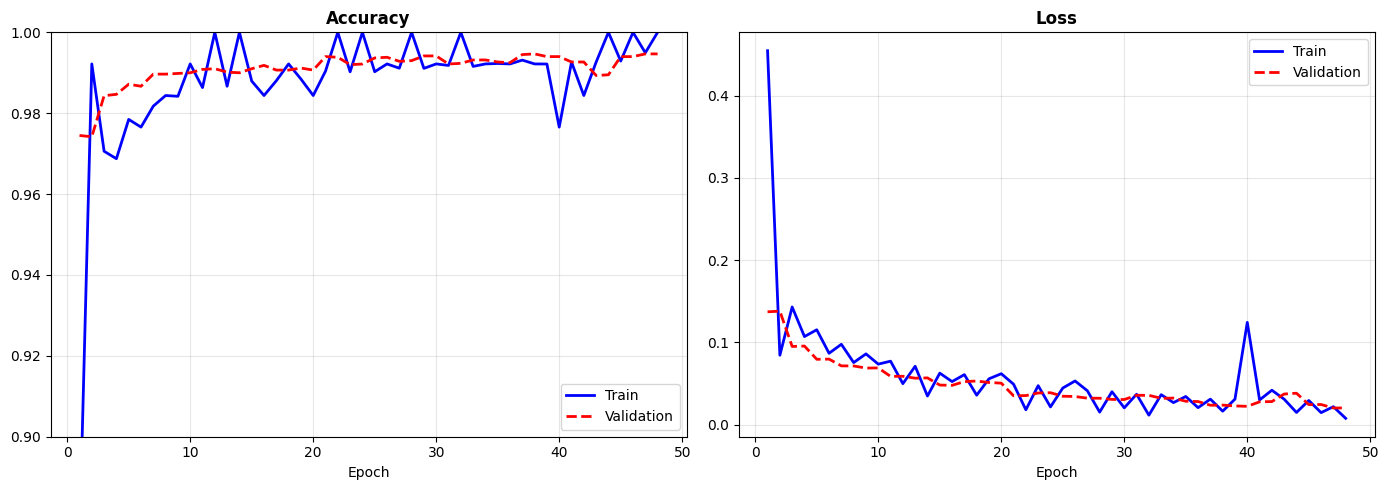

In [9]:
acc      = history.history['accuracy']
val_acc  = history.history['val_accuracy']
loss     = history.history['loss']
val_loss = history.history['val_loss']
ep       = range(1, len(acc)+1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(ep, acc, 'b-', lw=2, label='Train')
ax1.plot(ep, val_acc, 'r--', lw=2, label='Validation')
ax1.set_title('Accuracy', fontweight='bold'); ax1.set_ylim([0.9, 1.0])
ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep, loss, 'b-', lw=2, label='Train')
ax2.plot(ep, val_loss, 'r--', lw=2, label='Validation')
ax2.set_title('Loss', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
model.load_weights(MODEL_PATH)
test_loss, test_acc = model.evaluate(X_test, y_test_oh, verbose=0, batch_size=256)
print('='*40)
print(f'Test Loss    : {test_loss:.4f}')
print(f'Test Accuracy: {test_acc*100:.2f}%')
print('='*40)

Test Loss    : 0.0222
Test Accuracy: 99.54%


In [11]:
y_pred_prob = model.predict(X_test, batch_size=256, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
print(classification_report(y_test, y_pred, target_names=[str(i) for i in range(10)]))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       1.00      1.00      1.00      1032
           3       1.00      1.00      1.00      1010
           4       0.99      0.99      0.99       982
           5       0.99      1.00      0.99       892
           6       1.00      0.99      1.00       958
           7       1.00      1.00      1.00      1028
           8       0.99      1.00      1.00       974
           9       0.99      0.99      0.99      1009

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



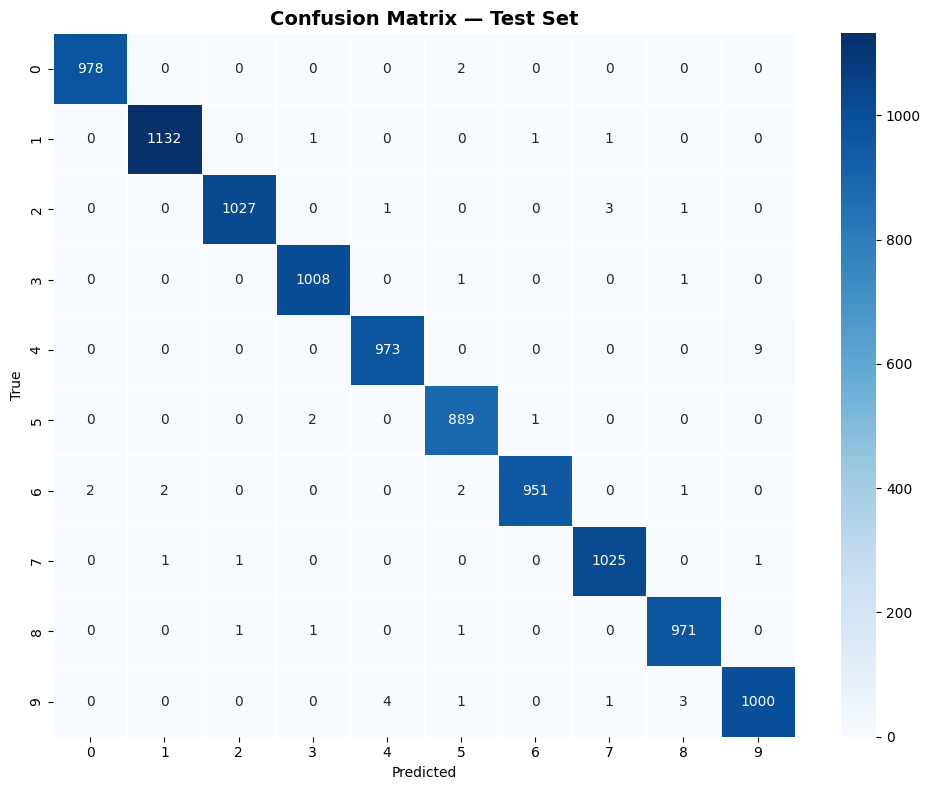

In [12]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10), linewidths=0.5)
plt.title('Confusion Matrix — Test Set', fontsize=14, fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

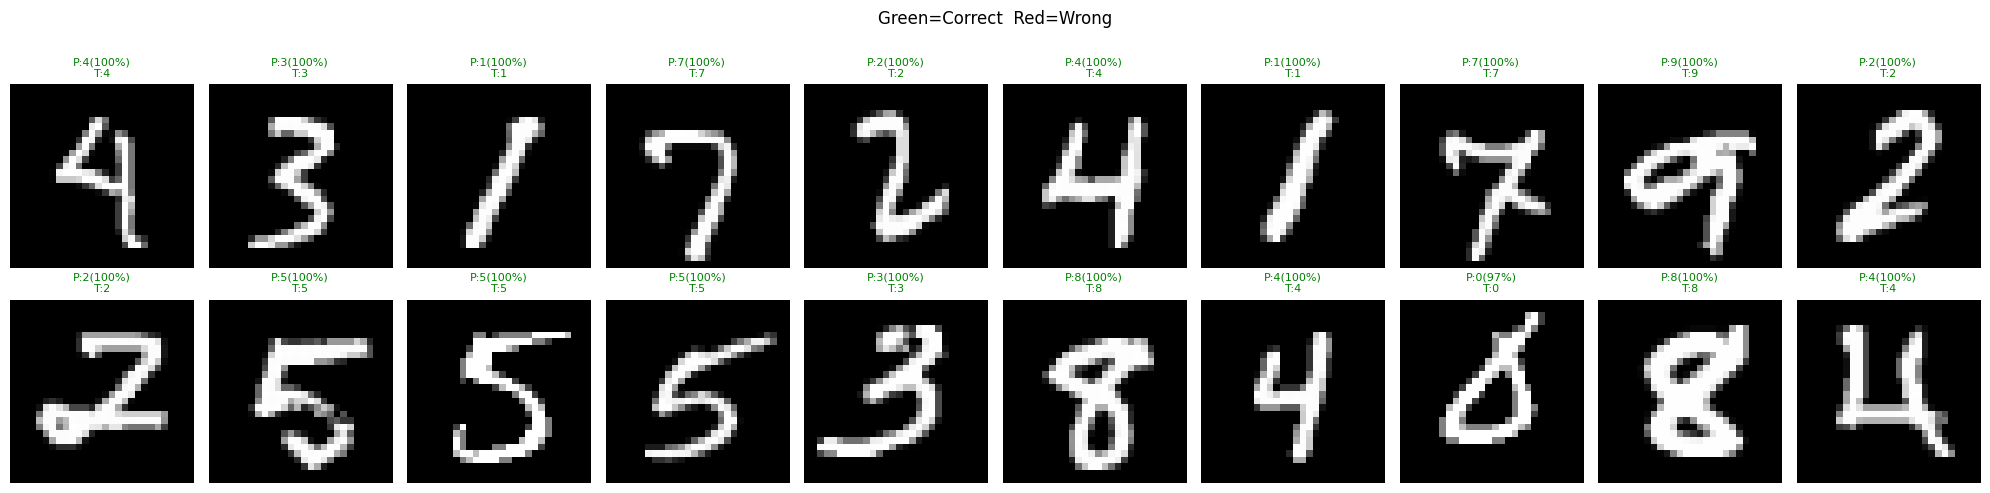

In [13]:
rng  = np.random.default_rng(7)
idxs = rng.choice(len(X_test), 20, replace=False)
fig, axes = plt.subplots(2, 10, figsize=(20, 5))
for i, idx in enumerate(idxs):
    ax = axes[i//10, i%10]
    ax.imshow(X_test[idx,:,:,0], cmap='gray')
    pred = y_pred[idx]; true = y_test[idx]
    conf = y_pred_prob[idx][pred]*100
    ax.set_title(f'P:{pred}({conf:.0f}%)\nT:{true}',
                 fontsize=8, color='green' if pred==true else 'red')
    ax.axis('off')
plt.suptitle('Green=Correct  Red=Wrong', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

Misclassified: 46/10000 (0.46%)


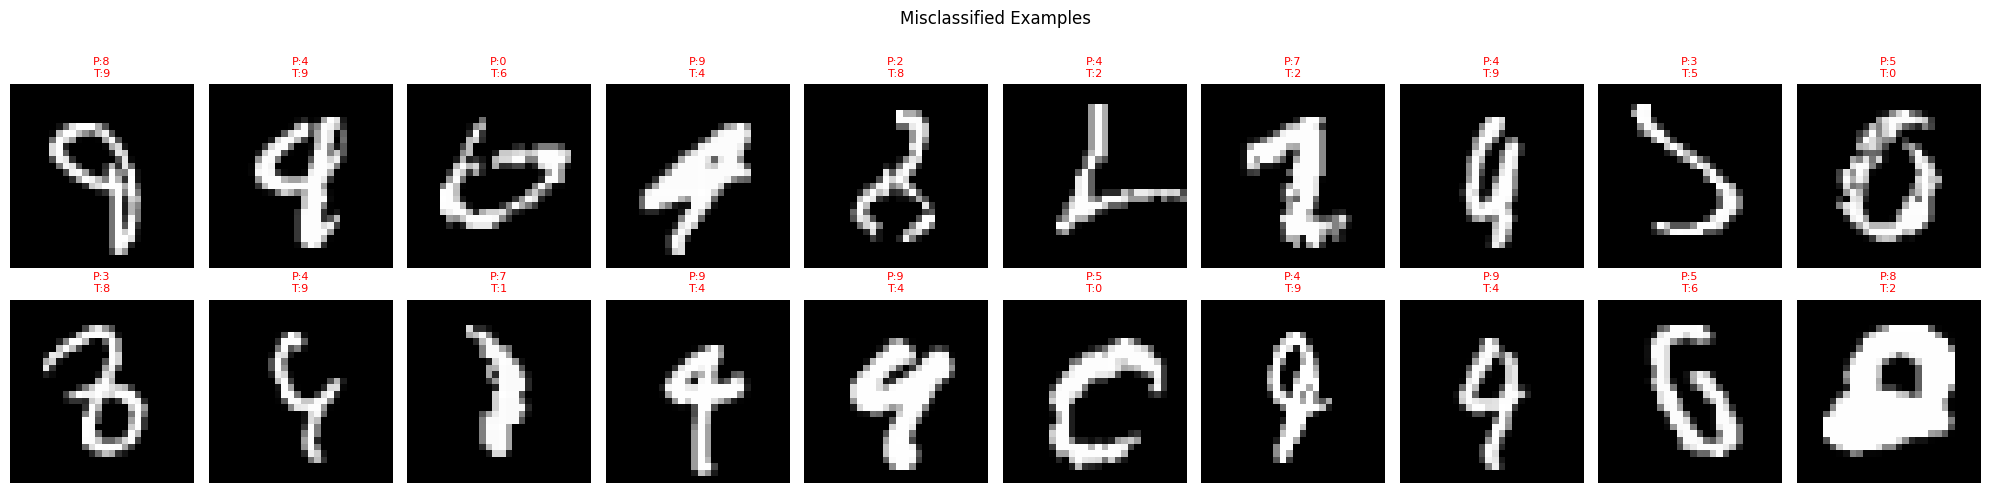

In [14]:
wrong = np.where(y_pred != y_test)[0]
print(f'Misclassified: {len(wrong)}/{len(y_test)} ({len(wrong)/len(y_test)*100:.2f}%)')
show = min(20, len(wrong))
fig, axes = plt.subplots(2, 10, figsize=(20, 5))
for i, idx in enumerate(wrong[:show]):
    ax = axes[i//10, i%10]
    ax.imshow(X_test[idx,:,:,0], cmap='gray')
    pred = y_pred[idx]; true = y_test[idx]
    ax.set_title(f'P:{pred}\nT:{true}', fontsize=8, color='red')
    ax.axis('off')
plt.suptitle('Misclassified Examples', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

In [15]:
model.save(MODEL_PATH)
print(f'Model saved: {MODEL_PATH}')
print('Now run:  streamlit run app.py')

Model saved: mnist_cnn.h5
Now run:  streamlit run app.py
